## **7 Exercise.**
### **Implement an End to End CNN Model for Image Classification Task.**

**Objective**

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.

In [1]:
!unzip "/content/FruitinAmazon.zip" -d /content/extracted_data/

Archive:  /content/FruitinAmazon.zip
  inflating: /content/extracted_data/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: /content/extracted_data/FruitinAmazon/test/

### **Task 1: Data Understanding and Visualization:**

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

In [2]:
# Define dataset paths
train_dir = "/content/extracted_data/FruitinAmazon/train"
test_dir = "/content/extracted_data/FruitinAmazon/test"

In [3]:
random.seed(42)
# Get the list of class directories from the train folder
class_names = sorted(os.listdir(train_dir))

# Select one random image from each class
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    if images:
        random_image = random.choice(images)  # Randomly select an image
        img_path = os.path.join(class_path, random_image)
        img = Image.open(img_path).convert("RGB")  # Keep RGB format
        selected_images.append(np.array(img))
        selected_labels.append(class_name)

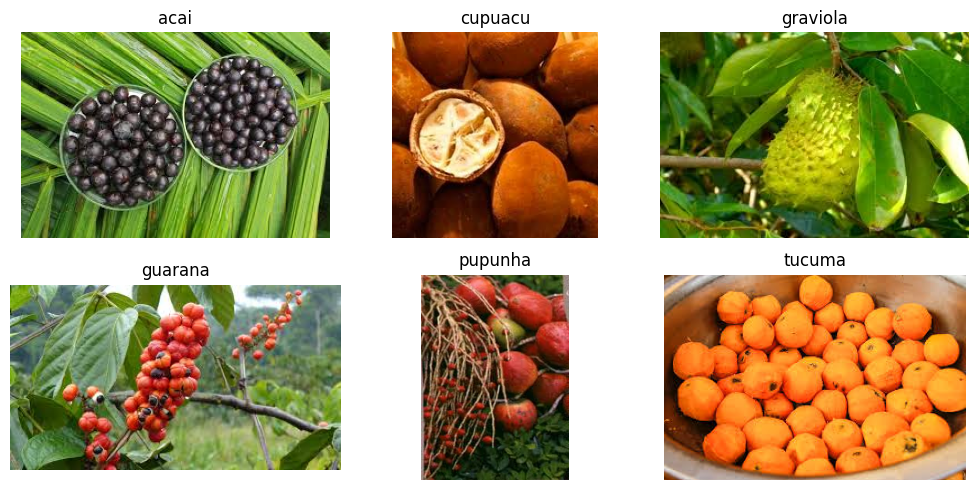

In [4]:
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

# Display the images in a grid format
plt.figure(figsize=(10, 5))
for i, (img, label) in enumerate(zip(selected_images, selected_labels)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)  # Display RGB images
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


2. Check for Corrupted Image:

In [5]:
def remove_corrupted_images(directory):
    corrupted_images = []

    # Iterate through each class subdirectory
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):  # Ensure it's a directory
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)
                try:
                    with Image.open(image_path) as img:
                        img.verify()  # Verify if the image is not corrupted
                except (IOError, SyntaxError):
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")

    if not corrupted_images:
        print("No Corrupted Images Found.")


In [6]:
# Run the function to check and remove corrupted images
remove_corrupted_images(train_dir)

No Corrupted Images Found.


### **Task 2: Loading and Preprocessing Image Data in keras:**

In [16]:
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  test_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


### **Task 3 - Implement a CNN with**
Follow the following Structure and Hyper - parameters:
Convolutional Architecture:
- Convolutional Layer 1:
  - Filter Size (F): (3, 3)
  - Number of Filters (k): 32
  - Padding (P): same
  - Stride (s): 1
- Activation Layer: ReLU activation
- Pooling Layer 1: Max pooling
  - Filter Size (F): (2, 2)
  - Stride (s): 2
- Convolutional Layer 2:
  - Filter Size (F): (3, 3)
  - Number of Filters (k): 32
  - Padding (P): same
  - Stride (s): 1
- Activation Layer: ReLU activation
- Pooling Layer 2: Max pooling
  - Filter Size (F): (2, 2)
  - Stride (s): 2

In [17]:
model = keras.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Network
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Task 4: Compile the Model**
Model Compilation
- Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [18]:
model.compile(
    optimizer = 'adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

### **Task 4: Train the Model**
Model Training
- Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
- Use val ds for validation.

- Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [20]:
# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", restore_best_weights=True, patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
    train_ds,
    batch_size = 16,
    epochs = 250,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 699ms/step - accuracy: 0.1623 - loss: 1.8133 - val_accuracy: 0.7778 - val_loss: 1.4513
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4054 - loss: 1.5666 - val_accuracy: 0.7778 - val_loss: 0.9278
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3398 - loss: 1.2847 - val_accuracy: 0.6111 - val_loss: 1.4356
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5191 - loss: 1.0920 - val_accuracy: 0.7778 - val_loss: 0.5677
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7873 - loss: 0.7604 - val_accuracy: 0.8889 - val_loss: 0.5118
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8828 - loss: 0.4947 - val_accuracy: 0.8333 - val_loss: 0.5619
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9418 - loss: 0.3686 - val_accuracy: 0.8333 - val_loss: 0.4796
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9527 - loss: 0.2494 - val_accuracy: 0.8333 - val

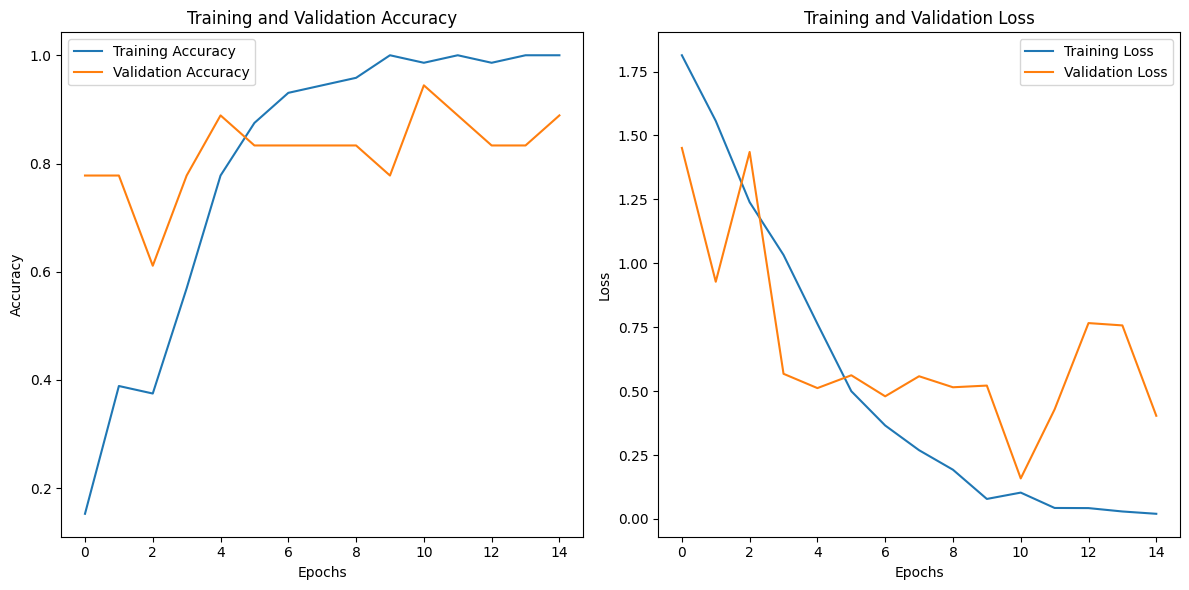

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### **Task 5: Evaluate the Model**
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [22]:
print("\nEvaluating model on validation set:")
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


Evaluating model on validation set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9444 - loss: 0.1584
Test accuracy: 0.9444
Test loss: 0.1584


### **Task 6: Save and Load the Model**
Model Saving and Loading
• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

In [23]:
# Save the model
model.save('fruit_classification_model.h5')
print("Model saved to 'fruit_classification_model.h5'")

# Load the model
loaded_model = keras.models.load_model('fruit_classification_model.h5')
print("Model loaded successfully")


Model saved to 'fruit_classification_model.h5'
Model loaded successfully


In [24]:
import numpy as np

# Make predictions on the test dataset
predictions = model.predict(test_ds)

# Convert predictions from probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Extract true labels from test_ds
true_labels = np.concatenate([y.numpy() for _, y in test_ds])  # Convert dataset labels to NumPy array

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {true_labels[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
Predicted label for first image: 0
True label for first image: 0


### **Task 7: Predictions and Classification Report**
Making Predictions
- Use model.predict() to make predictions on test images.
- Convert the model’s predicted probabilities to digit labels using np.argmax().
- Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [25]:
from sklearn.metrics import classification_report

# Print the classification report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.57      0.80      0.67         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.83        30
   macro avg       0.87      0.83      0.82        30
weighted avg       0.87      0.83      0.82        30

